In [3]:
#loading the .arff file
from scipy.io import arff
import pandas as pd

data, meta = arff.loadarff('Training Dataset.arff')
df = pd.DataFrame(data)
df.head()


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,b'-1',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'-1',b'1',...,b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',b'1',b'-1',b'-1'
1,b'1',b'1',b'1',b'1',b'1',b'-1',b'0',b'1',b'-1',b'1',...,b'1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'-1'
2,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'-1',b'1',...,b'1',b'1',b'1',b'-1',b'1',b'-1',b'1',b'0',b'-1',b'-1'
3,b'1',b'0',b'1',b'1',b'1',b'-1',b'-1',b'-1',b'1',b'1',...,b'1',b'1',b'-1',b'-1',b'1',b'-1',b'1',b'-1',b'1',b'-1'
4,b'1',b'0',b'-1',b'1',b'1',b'-1',b'1',b'1',b'-1',b'1',...,b'-1',b'1',b'-1',b'-1',b'0',b'-1',b'1',b'1',b'1',b'1'


In [4]:
#converting target class from byte to integer
df['Result'] = df['Result'].apply(lambda x: int(x))


In [5]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


In [6]:
#featured engineering; scaling 

from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('Result', axis=1)
y = df['Result']

# Apply scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optional: Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


In [7]:
#check class imbalance
print(y.value_counts())  # Check number of -1 (legit) vs 1 (phishing)


Result
 1    6157
-1    4898
Name: count, dtype: int64


In [8]:
#Balance with SMOTE (Synthetic Minority Over-sampling Technique)
#SMOT Generates synthetic samples of the minority class
#SMOT Prevents overfitting caused by random oversampling

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print(f"Balanced dataset shape: {y_resampled.value_counts()}")


Balanced dataset shape: Result
-1    6157
 1    6157
Name: count, dtype: int64


In [14]:
#train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=12, stratify=y_resampled
)


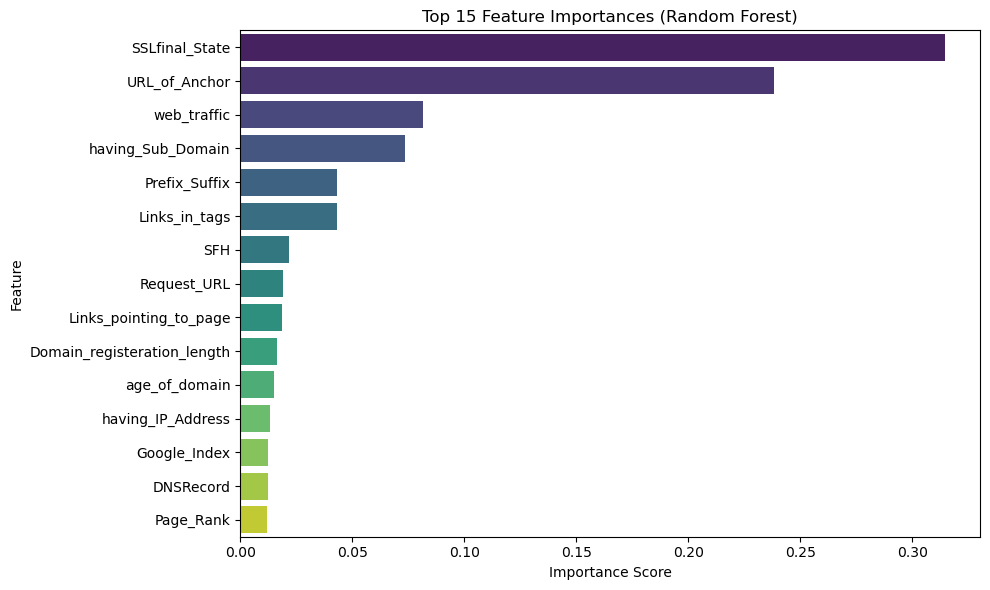

In [20]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_resampled, y_resampled)

# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns  # Use original feature names

# Create DataFrame for importances
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [16]:
print("Final shapes:", X_train.shape, X_test.shape)

Final shapes: (9851, 30) (2463, 30)


In [21]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)


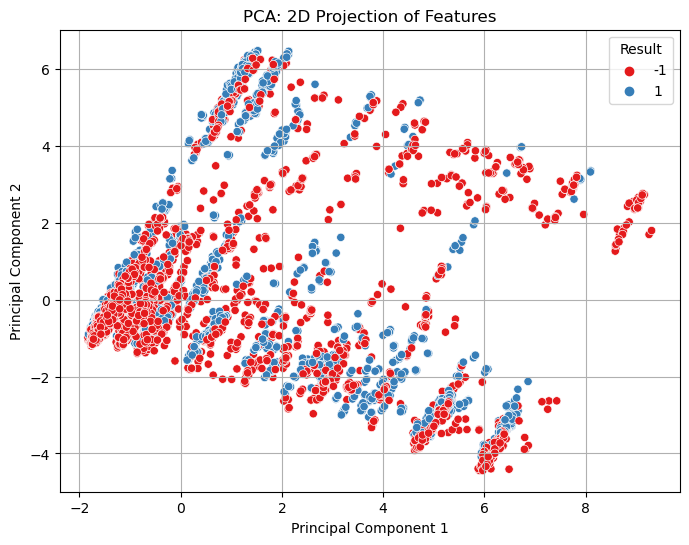

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PCA
pca = PCA(n_components=2)  # You can change n_components based on use-case
X_pca = pca.fit_transform(X_resampled)

# Create a DataFrame with PCA components for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Result'] = y_resampled.values

# Plot PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Result', palette='Set1')
plt.title('PCA: 2D Projection of Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

#